# Notebook 1: Data Curation

This notebook loads the ligand library and prepares compounds for docking.

**Target:** Androgen Receptor (PDB: 2AXA)  
**Compounds:** 5 initial candidates (metformin, quercetin, resveratrol, naringenin, kaempferol)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!
Pandas version: 2.3.3


In [2]:
# Load the CSV file
csv_path = "../data/raw/ligand_library.csv"
ligands = pd.read_csv(csv_path)

print(f"Loaded {len(ligands)} compounds:")
print(ligands)

Loaded 5 compounds:
          name                                      smiles           source  \
0    metformin                           CN(C)C(=N)NC(=N)N     FDA approved   
1    quercetin  O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12  natural product   
2  resveratrol                Oc1ccc(C=Cc2cc(O)cc(O)c2)cc1  natural product   
3   naringenin     O=C1C=C(c2ccc(O)cc2)OC2=CC(O)=CC(O)=C12  natural product   
4   kaempferol     O=c1c(O)c(-c2ccc(O)cc2)oc2cc(O)cc(O)c12  natural product   

      status  
0  candidate  
1  candidate  
2  candidate  
3  candidate  
4  candidate  


In [3]:
from rdkit import Chem
from rdkit.Chem import Descriptors

def get_molecular_weight(smiles):
    """Calculate molecular weight from SMILES."""
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return Descriptors.MolWt(mol)
    return None

# Add molecular weight column
ligands['molecular_weight'] = ligands['smiles'].apply(get_molecular_weight)

print("Molecular weights calculated:")
print(ligands[['name', 'molecular_weight']])

Molecular weights calculated:
          name  molecular_weight
0    metformin           129.167
1    quercetin           302.238
2  resveratrol           228.247
3   naringenin           270.240
4   kaempferol           286.239


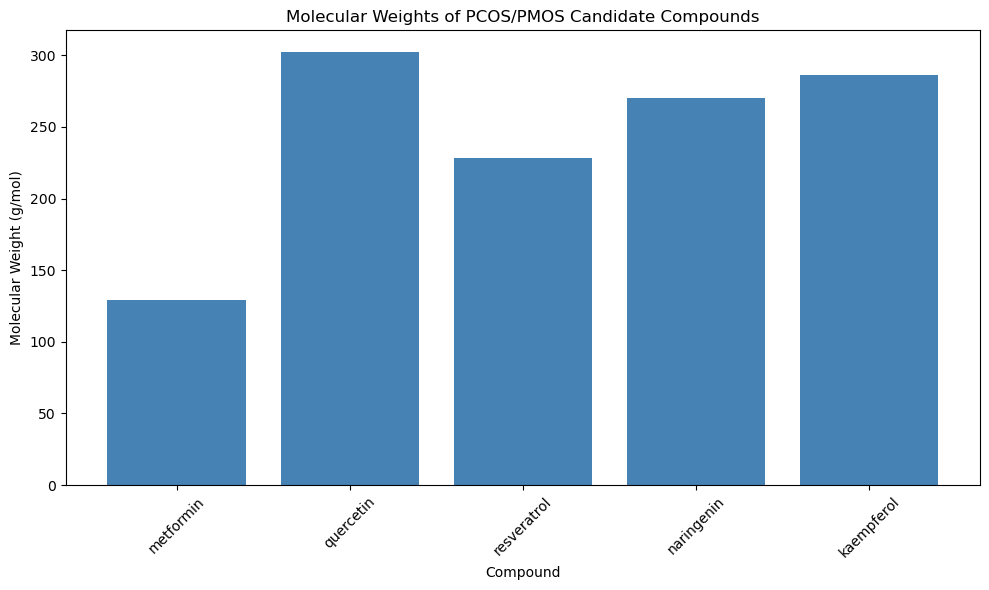

Figure saved to figures/molecular_weights.png


In [4]:
# Create a bar chart of molecular weights
plt.figure(figsize=(10, 6))
plt.bar(ligands['name'], ligands['molecular_weight'], color='steelblue')
plt.xlabel('Compound')
plt.ylabel('Molecular Weight (g/mol)')
plt.title('Molecular Weights of PCOS/PMOS Candidate Compounds')
plt.xticks(rotation=45)
plt.tight_layout()

# Save the figure
plt.savefig('../figures/molecular_weights.png', dpi=300)
plt.show()

print("Figure saved to figures/molecular_weights.png")